#### Experiment 7a
- 1D
- Linear variation - electrode exponents vary from -1 to -1.5 with 1 outlier
- Compute PSD in both log and linear space
- 5 electrodes
- Aperiodic noise only
- Average by PSD and SpecMod. Do not produce plots, save outputs
- Load in JSON output summaries and plot a single combined plot

In [1]:
# Imports for functionality 
from dissertation_simulations.time_series import sweep_electrodes_ts_2D
from dissertation_simulations.psd import sweep_electrodes_psd_2D
from dissertation_simulations.spec_mod import sweep_electrodes_specmod_2D
from dissertation_simulations.exponents import generate_spatial_exponent_matrix, generate_2D_exponent_matrix
from dissertation_simulations.plotting import plot_summary_boxplots

import numpy as np
import json

from scipy.stats import ttest_rel

In [2]:
# Define exponent matrix
exp_matrix = generate_2D_exponent_matrix(grid_shape=(1, 5), exp_range=(-2, -1), gradient_axis="cols", outlier={
        "value": -3,
        "location": "random"
    })
exp_matrix

array([[-2.  , -3.  , -1.5 , -1.25, -1.  ]])

{'exponent': array([[-2.  , -3.  , -1.5 , -1.25, -1.  ]]), 'psd_average_space': 'linear'}
{'exponent': array([[-2.  , -3.  , -1.5 , -1.25, -1.  ]]), 'psd_average_space': 'log'}


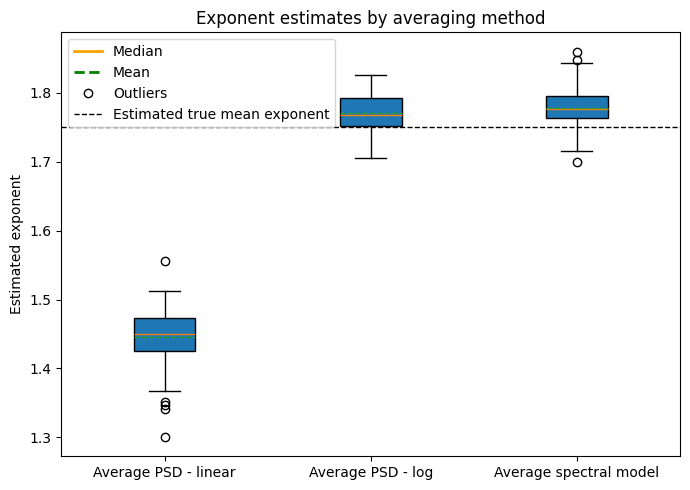

In [3]:
# Average the PSD - linear space
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D(grid_range=[(1, 5)], exponent=exp_matrix, psd_average_space="linear",
                                                              n_repeats=100, plot=False, return_full=True)

exp7a_result1_psd_linear = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7aresults1_psd_linear_exp_matrix_cols_-1-2_outlier.json", "w") as f:
    json.dump(exp7a_result1_psd_linear, f, indent=4)

# Average the PSD - log space
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D(grid_range=[(1, 5)], exponent=exp_matrix, psd_average_space="log",
                                                              n_repeats=100, plot=False, return_full=True)

exp7a_result2_psd_log = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7aresults2_psd_log_exp_matrix_cols_-1-2_outlier.json", "w") as f:
    json.dump(exp7a_result2_psd_log, f, indent=4)

# Average the SpecMod
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_specmod_2D(grid_range=[(1, 5)], exponent=exp_matrix, 
                                                              n_repeats=100, plot=False, return_full=True)

exp7a_result3_specmod = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7aresults3_specmod_exp_matrix_cols_-1-2_outlier.json", "w") as f:
    json.dump(exp7a_result3_specmod, f, indent=4)


# Loading summaries and combining into a single plot
summary_paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7aresults1_psd_linear_exp_matrix_cols_-1-2_outlier.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7aresults2_psd_log_exp_matrix_cols_-1-2_outlier.json", 
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7aresults3_specmod_exp_matrix_cols_-1-2_outlier.json"
]

labels = [
    "Average PSD - linear",
    "Average PSD - log", 
    "Average spectral model"
]

fig, ax = plot_summary_boxplots(
    summary_paths=summary_paths,
    labels=labels,
    true_mean_exp=np.mean(-exp_matrix)
)

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\1D electrodes\Combined plots\exp7a_combined_plot_1D_exp_matrix_cols_-1-2_outlier.png", dpi=300, bbox_inches="tight")

In [4]:
# Paired t-tests
with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7aresults1_psd_linear_exp_matrix_cols_-1-2_outlier.json") as f:
    psd_linear_data = json.load(f)

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7aresults2_psd_log_exp_matrix_cols_-1-2_outlier.json") as f:
    psd_log_data = json.load(f)

with open (r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7aresults3_specmod_exp_matrix_cols_-1-2_outlier.json") as f:
    spec_data = json.load(f)

psd_linear = np.array(psd_linear_data["all_distributions"][0])
psd_log = np.array(psd_log_data["all_distributions"][0])
spec = np.array(spec_data["all_distributions"][0])

t, p = ttest_rel(psd_linear, psd_log)
print(f"PSD - linear averaging vs PSD - log averaging: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd_linear, spec)
print(f"PSD - linear averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd_log, spec)
print(f"PSD - log averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

PSD - linear averaging vs PSD - log averaging: t = -61.188, p = 0.00000
PSD - linear averaging vs Spectral model: t = -60.244, p = 0.00000
PSD - log averaging vs Spectral model: t = -2.058, p = 0.04221


#### Experiment 7b
- 1D
- Linear variation - electrode exponents vary from -1 to -1.5 - "middle out", with 1 outlier
- Compute PSD in both log and linear space
- 5 electrodes
- Aperiodic noise only
- Average by PSD and SpecMod. Do not produce plots, save outputs
- Load in JSON output summaries and plot a single combined plot

In [5]:
# Define exponent matrix
exp_matrix = generate_spatial_exponent_matrix(grid_shape=(1, 5), exp_min=-1.5, exp_max=-1, pattern="middle", outlier={
        "value": -3,
        "location": "random"
    })
exp_matrix

array([[-1.  , -1.25, -1.5 , -3.  , -1.  ]])

{'exponent': array([[-1.  , -1.25, -1.5 , -3.  , -1.  ]]), 'psd_average_space': 'linear'}
{'exponent': array([[-1.  , -1.25, -1.5 , -3.  , -1.  ]]), 'psd_average_space': 'log'}


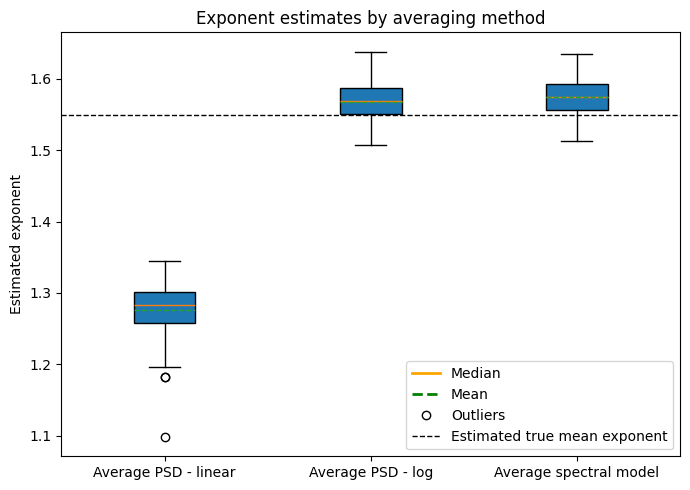

In [6]:
# Average the PSD - linear space
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D(grid_range=[(1, 5)], exponent=exp_matrix, psd_average_space="linear",
                                                              n_repeats=100, plot=False, return_full=True)

exp7b_result1_psd_linear = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7bresults1_psd_linear_exp_matrix_middle_-1-1.5_outlier.json", "w") as f:
    json.dump(exp7b_result1_psd_linear, f, indent=4)

# Average the PSD - log space
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D(grid_range=[(1, 5)], exponent=exp_matrix, psd_average_space="log",
                                                              n_repeats=100, plot=False, return_full=True)

exp7b_result2_psd_log = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7bresults2_psd_log_exp_matrix_middle_-1-1.5_outlier.json", "w") as f:
    json.dump(exp7b_result2_psd_log, f, indent=4)

# Average the SpecMod
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_specmod_2D(grid_range=[(1, 5)], exponent=exp_matrix, 
                                                              n_repeats=100, plot=False, return_full=True)

exp7b_result3_specmod = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7bresults3_specmod_exp_matrix_middle_-1-1.5_outlier.json", "w") as f:
    json.dump(exp7b_result3_specmod, f, indent=4)


# Loading summaries and combining into a single plot
summary_paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7bresults1_psd_linear_exp_matrix_middle_-1-1.5_outlier.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7bresults2_psd_log_exp_matrix_middle_-1-1.5_outlier.json", 
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7bresults3_specmod_exp_matrix_middle_-1-1.5_outlier.json"
]

labels = [
    "Average PSD - linear",
    "Average PSD - log", 
    "Average spectral model"
]

fig, ax = plot_summary_boxplots(
    summary_paths=summary_paths,
    labels=labels,
    true_mean_exp=np.mean(-exp_matrix)
)

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\1D electrodes\Combined plots\exp7b_combined_plot_1D_exp_matrix_middle_-1-1.5_outlier.png", dpi=300, bbox_inches="tight")

In [7]:
# Paired t-tests
with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7bresults1_psd_linear_exp_matrix_middle_-1-1.5_outlier.json") as f:
    psd_linear_data = json.load(f)

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7bresults2_psd_log_exp_matrix_middle_-1-1.5_outlier.json") as f:
    psd_log_data = json.load(f)

with open (r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7bresults3_specmod_exp_matrix_middle_-1-1.5_outlier.json") as f:
    spec_data = json.load(f)

psd_linear = np.array(psd_linear_data["all_distributions"][0])
psd_log = np.array(psd_log_data["all_distributions"][0])
spec = np.array(spec_data["all_distributions"][0])

t, p = ttest_rel(psd_linear, psd_log)
print(f"PSD - linear averaging vs PSD - log averaging: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd_linear, spec)
print(f"PSD - linear averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd_log, spec)
print(f"PSD - log averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

PSD - linear averaging vs PSD - log averaging: t = -60.513, p = 0.00000
PSD - linear averaging vs Spectral model: t = -61.108, p = 0.00000
PSD - log averaging vs Spectral model: t = -1.928, p = 0.05674


#### Experiment 7c
- 1D
- Linear variation - electrode exponents vary from -1 to -1.5 - "middle in", with 1 outlier
- Compute PSD in both log and linear space
- 5 electrodes
- Aperiodic noise only
- Average by PSD and SpecMod. Do not produce plots, save outputs
- Load in JSON output summaries and plot a single combined plot

In [8]:
# Define exponent matrix
exp_matrix = generate_spatial_exponent_matrix(grid_shape=(1, 5), exp_min=-1, exp_max=-1.5, pattern="middle", outlier={
        "value": -3,
        "location": "last"
    })
exp_matrix

array([[-1.5 , -1.25, -1.  , -1.25, -3.  ]])

{'exponent': array([[-1.5 , -1.25, -1.  , -1.25, -3.  ]]), 'psd_average_space': 'linear'}
{'exponent': array([[-1.5 , -1.25, -1.  , -1.25, -3.  ]]), 'psd_average_space': 'log'}


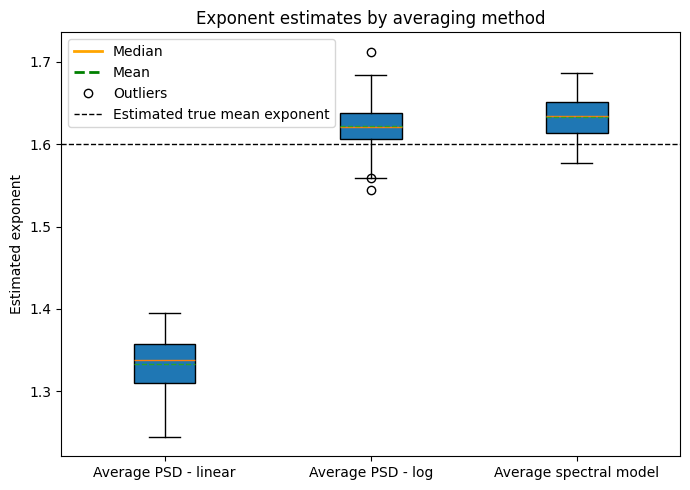

In [9]:
# Average the PSD - linear space
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D(grid_range=[(1, 5)], exponent=exp_matrix, psd_average_space="linear",
                                                              n_repeats=100, plot=False, return_full=True)

exp7c_result1_psd_linear = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7cresults1_psd_linear_exp_matrix_middle_-1-1.5_outlier.json", "w") as f:
    json.dump(exp7c_result1_psd_linear, f, indent=4)

# Average the PSD - log space
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D(grid_range=[(1, 5)], exponent=exp_matrix, psd_average_space="log",
                                                              n_repeats=100, plot=False, return_full=True)

exp7c_result2_psd_log = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7cresults2_psd_log_exp_matrix_middle_-1-1.5_outlier.json", "w") as f:
    json.dump(exp7c_result2_psd_log, f, indent=4)

# Average the SpecMod
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_specmod_2D(grid_range=[(1, 5)], exponent=exp_matrix, 
                                                              n_repeats=100, plot=False, return_full=True)

exp7c_result3_specmod = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7cresults3_specmod_exp_matrix_middle_-1-1.5_outlier.json", "w") as f:
    json.dump(exp7c_result3_specmod, f, indent=4)


# Loading summaries and combining into a single plot
summary_paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7cresults1_psd_linear_exp_matrix_middle_-1-1.5_outlier.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7cresults2_psd_log_exp_matrix_middle_-1-1.5_outlier.json", 
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7cresults3_specmod_exp_matrix_middle_-1-1.5_outlier.json"
]

labels = [
    "Average PSD - linear",
    "Average PSD - log", 
    "Average spectral model"
]

fig, ax = plot_summary_boxplots(
    summary_paths=summary_paths,
    labels=labels,
    true_mean_exp=np.mean(-exp_matrix)
)

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\1D electrodes\Combined plots\exp7c_combined_plot_1D_exp_matrix_middle_-1-1.5_outlier.png", dpi=300, bbox_inches="tight")

In [10]:
# Paired t-tests
with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7cresults1_psd_linear_exp_matrix_middle_-1-1.5_outlier.json") as f:
    psd_linear_data = json.load(f)

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7cresults2_psd_log_exp_matrix_middle_-1-1.5_outlier.json") as f:
    psd_log_data = json.load(f)

with open (r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7cresults3_specmod_exp_matrix_middle_-1-1.5_outlier.json") as f:
    spec_data = json.load(f)

psd_linear = np.array(psd_linear_data["all_distributions"][0])
psd_log = np.array(psd_log_data["all_distributions"][0])
spec = np.array(spec_data["all_distributions"][0])

t, p = ttest_rel(psd_linear, psd_log)
print(f"PSD - linear averaging vs PSD - log averaging: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd_linear, spec)
print(f"PSD - linear averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd_log, spec)
print(f"PSD - log averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

PSD - linear averaging vs PSD - log averaging: t = -69.894, p = 0.00000
PSD - linear averaging vs Spectral model: t = -79.046, p = 0.00000
PSD - log averaging vs Spectral model: t = -2.604, p = 0.01062
